In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, make_scorer, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
data_path = 'data/'
df_lists = []

customers_df = pd.read_csv(data_path + 'olist_customers_dataset.csv')
geolocation_df = pd.read_csv(data_path + 'olist_geolocation_dataset.csv')
order_items_df = pd.read_csv(data_path + 'olist_order_items_dataset.csv')
order_payments_df = pd.read_csv(data_path + 'olist_order_payments_dataset.csv')
order_reviews_df = pd.read_csv(data_path + 'olist_order_reviews_dataset.csv')
orders_df = pd.read_csv(data_path + 'olist_orders_dataset.csv')
products_df = pd.read_csv(data_path + 'olist_products_dataset.csv')
sellers_df = pd.read_csv(data_path + 'olist_sellers_dataset.csv')
category_translation_df = pd.read_csv(data_path + 'product_category_name_translation.csv')

#### Manejo de valores nulos en productos

In [3]:

products_df['product_category_name'] = products_df['product_category_name'].fillna('Desconocido')
products_df['product_photos_qty'] = products_df['product_photos_qty'].fillna(0)
for col in ['product_name_lenght', 'product_description_lenght', 'product_weight_g', 
            'product_length_cm', 'product_height_cm', 'product_width_cm']:
    products_df[col] = products_df[col].fillna(products_df[col].median())

orders_df['delivered'] = orders_df['order_delivered_customer_date'].notnull().astype(int)

#### DATASET COMBINADO

In [4]:
# Unir orders_df con customers_df
merged_df = pd.merge(orders_df, customers_df, on='customer_id', how='left')

# Unir con order_reviews_df (primera reseña por pedido)
order_reviews_unique = order_reviews_df.sort_values('review_creation_date').groupby('order_id').first()[
    ['review_score', 'review_comment_message']
].reset_index()
merged_df = pd.merge(merged_df, order_reviews_unique, on='order_id', how='left')

# ver si hay comentarios
merged_df['has_comment'] = (~merged_df['review_comment_message'].isna()).astype(int)


# Unir con order_items_df (agregados por pedido)
order_items_agg = order_items_df.groupby('order_id').agg({
    'price': 'mean',  
    'freight_value': 'mean',  
    'order_item_id': 'count',
    'shipping_limit_date': 'max'
}).reset_index().rename(columns={
    'price': 'avg_item_price',
    'freight_value': 'avg_freight_value',
    'order_item_id': 'num_items',
    'shipping_limit_date': 'shipping_limit_date'
})
merged_df = pd.merge(merged_df, order_items_agg, on='order_id', how='left')

# Unir con productos
# Obtener product_id principal y seller_id por pedido
order_items_info = order_items_df.groupby('order_id').agg({
    'product_id': 'first',
    'seller_id': 'first'
}).reset_index()

merged_df = pd.merge(merged_df, order_items_info, on='order_id', how='left')
merged_df = pd.merge(merged_df, products_df, on='product_id', how='left')

# Unir con category_translation_df
merged_df = pd.merge(merged_df, category_translation_df, on='product_category_name', how='left')

# Unir con order_payments_df (suma del valor pagado)
order_payments_agg = order_payments_df.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': lambda x: x.value_counts().index[0]  # Tipo de pago más frecuente
}).reset_index().rename(columns={
    'payment_value': 'total_payment',
    'payment_type': 'main_payment_type'
})
merged_df = pd.merge(merged_df, order_payments_agg, on='order_id', how='left')

# Unir con sellers_df
merged_df = pd.merge(merged_df, sellers_df, on='seller_id', how='left')

#### MANEJO DE VALORES NULOS

In [5]:
numeric_cols = [
    'review_score', 'avg_item_price', 'avg_freight_value', 'num_items',
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'total_payment'
]

for col in numeric_cols:
    merged_df[col] = merged_df[col].fillna(merged_df[col].median())

# Manejo de nulos en columnas categóricas
merged_df['product_category_name'] = merged_df['product_category_name'].fillna('Desconocido')
merged_df['product_category_name_english'] = merged_df['product_category_name_english'].fillna('Unknown')
merged_df['seller_city'] = merged_df['seller_city'].fillna(merged_df['seller_city'].mode()[0])
merged_df['seller_state'] = merged_df['seller_state'].fillna(merged_df['seller_state'].mode()[0])
merged_df['main_payment_type'] = merged_df['main_payment_type'].fillna('credit_card')  # Valor más común

#### FEATURES TEMPORALES

In [6]:
# Convertir columnas de fechas a datetime
date_cols = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date', 'shipping_limit_date'
]

for col in date_cols:
    if col in merged_df.columns:
        merged_df[col] = pd.to_datetime(merged_df[col])

# Feature 1: Días laborables estimados de entrega
merged_df['estimated_delivery_days'] = merged_df.apply(
    lambda x: np.busday_count(
        x['order_approved_at'].date() if pd.notnull(x['order_approved_at']) else x['order_purchase_timestamp'].date(),
        x['order_estimated_delivery_date'].date()
    ) if pd.notnull(x['order_estimated_delivery_date']) else 0,
    axis=1
).clip(lower=0)

# Feature 2: Días laborables reales de entrega
merged_df['actual_delivery_days'] = merged_df.apply(
    lambda x: np.busday_count(
        x['order_approved_at'].date() if pd.notnull(x['order_approved_at']) else x['order_purchase_timestamp'].date(),
        x['order_delivered_customer_date'].date()
    ) if pd.notnull(x['order_delivered_customer_date']) else np.nan,
    axis=1
)
merged_df['actual_delivery_days'] = merged_df['actual_delivery_days'].clip(lower=0)

# Feature 3: Diferencia entre tiempo real y estimado
merged_df['delivery_time_delta'] = merged_df['actual_delivery_days'] - merged_df['estimated_delivery_days']

# Feature 4: Binario - ¿Llegó tarde?
merged_df['is_late'] = (merged_df['delivery_time_delta'] > 0).astype(int)

# Feature 5: Total de valor de orden
merged_df['total_order_value'] = (
    merged_df['avg_item_price'] * merged_df['num_items'] + 
    merged_df['avg_freight_value'] * merged_df['num_items']
)

# Feature 6: Ratio del flete
merged_df['freight_ratio'] = np.where(
    merged_df['avg_item_price'] > 0,
    merged_df['avg_freight_value'] / merged_df['avg_item_price'],
    0
)

# Feature 7: Día de la semana de compra
merged_df['purchase_day_of_week'] = merged_df['order_purchase_timestamp'].dt.dayofweek

# Feature 8: Hora de compra
merged_df['purchase_hour'] = merged_df['order_purchase_timestamp'].dt.hour

# Feature 9: Mes de compra
merged_df['purchase_month'] = merged_df['order_purchase_timestamp'].dt.month

# Feature 10: ¿Compra en fin de semana?
merged_df['weekend_purchase'] = (merged_df['purchase_day_of_week'] >= 5).astype(int)

# Feature 11: Tiempo entre compra y aprobación (en horas)
merged_df['purchase_to_approval_time'] = merged_df.apply(
    lambda x: (x['order_approved_at'] - x['order_purchase_timestamp']).total_seconds() / 3600 
    if pd.notnull(x['order_approved_at']) else 0,
    axis=1
).clip(lower=0)

# Feature 12: Tiempo entre aprobación y entrega al transportista (en horas)
merged_df['approval_to_carrier_time'] = merged_df.apply(
    lambda x: (x['order_delivered_carrier_date'] - x['order_approved_at']).total_seconds() / 3600 
    if pd.notnull(x['order_approved_at']) and pd.notnull(x['order_delivered_carrier_date']) else 0,
    axis=1
).clip(lower=0)

# Feature 13: Tiempo entre transportista y entrega al cliente (en horas)
merged_df['carrier_to_customer_time'] = merged_df.apply(
    lambda x: (x['order_delivered_customer_date'] - x['order_delivered_carrier_date']).total_seconds() / 3600 
    if pd.notnull(x['order_delivered_customer_date']) and pd.notnull(x['order_delivered_carrier_date']) else 0,
    axis=1
).clip(lower=0)

# Feature 14: Ratio de retraso
merged_df['delayed_days_ratio'] = np.where(
    merged_df['estimated_delivery_days'] > 0,
    merged_df['delivery_time_delta'] / merged_df['estimated_delivery_days'],
    0
)


In [7]:
# Feature 15: Volumen del producto
merged_df['product_volume'] = (
    merged_df['product_length_cm'] * 
    merged_df['product_height_cm'] * 
    merged_df['product_width_cm']
)

# Feature 16: Densidad del producto
merged_df['product_density'] = np.where(
    merged_df['product_volume'] > 0,
    merged_df['product_weight_g'] / merged_df['product_volume'],
    0
)

# Feature 17: Precio por peso
merged_df['price_per_weight'] = np.where(
    merged_df['product_weight_g'] > 0,
    merged_df['avg_item_price'] / merged_df['product_weight_g'],
    0
)

# Feature 18: ¿Cliente y vendedor en el mismo estado?
merged_df['seller_customer_same_state'] = (
    merged_df['seller_state'] == merged_df['customer_state']
).astype(int)

# Feature 19: Relación entre descripción y precio
merged_df['description_price_ratio'] = np.where(
    merged_df['avg_item_price'] > 0,
    merged_df['product_description_lenght'] / merged_df['avg_item_price'],
    0
)

# Feature 20: Relación entre fotos y precio
merged_df['photos_price_ratio'] = np.where(
    merged_df['avg_item_price'] > 0,
    merged_df['product_photos_qty'] / merged_df['avg_item_price'],
    0
)

# Feature 21: Categoría de review (binaria)
# 1-3 como Negativa/Neutral (0), 4-5 como Positiva (1)
merged_df['review_category'] = merged_df['review_score'].apply(
    lambda x: 1 if x >= 4 else 0
)

# Imputar nulos en features derivadas
merged_df['actual_delivery_days'] = merged_df['actual_delivery_days'].fillna(merged_df['actual_delivery_days'].median())
merged_df['delivery_time_delta'] = merged_df['delivery_time_delta'].fillna(0)
merged_df['approval_to_carrier_time'] = merged_df['approval_to_carrier_time'].fillna(merged_df['approval_to_carrier_time'].median())
merged_df['carrier_to_customer_time'] = merged_df['carrier_to_customer_time'].fillna(merged_df['carrier_to_customer_time'].median())



Correlaciones con review_score (top 10):
review_score                  1.000000
review_category               0.902481
delivered                     0.287151
seller_customer_same_state    0.054396
purchase_month                0.027427
product_photos_qty            0.024932
seller_zip_code_prefix        0.024785
photos_price_ratio            0.018257
description_price_ratio       0.017505
product_description_lenght    0.015274
purchase_hour                 0.005636
Name: review_score, dtype: float64


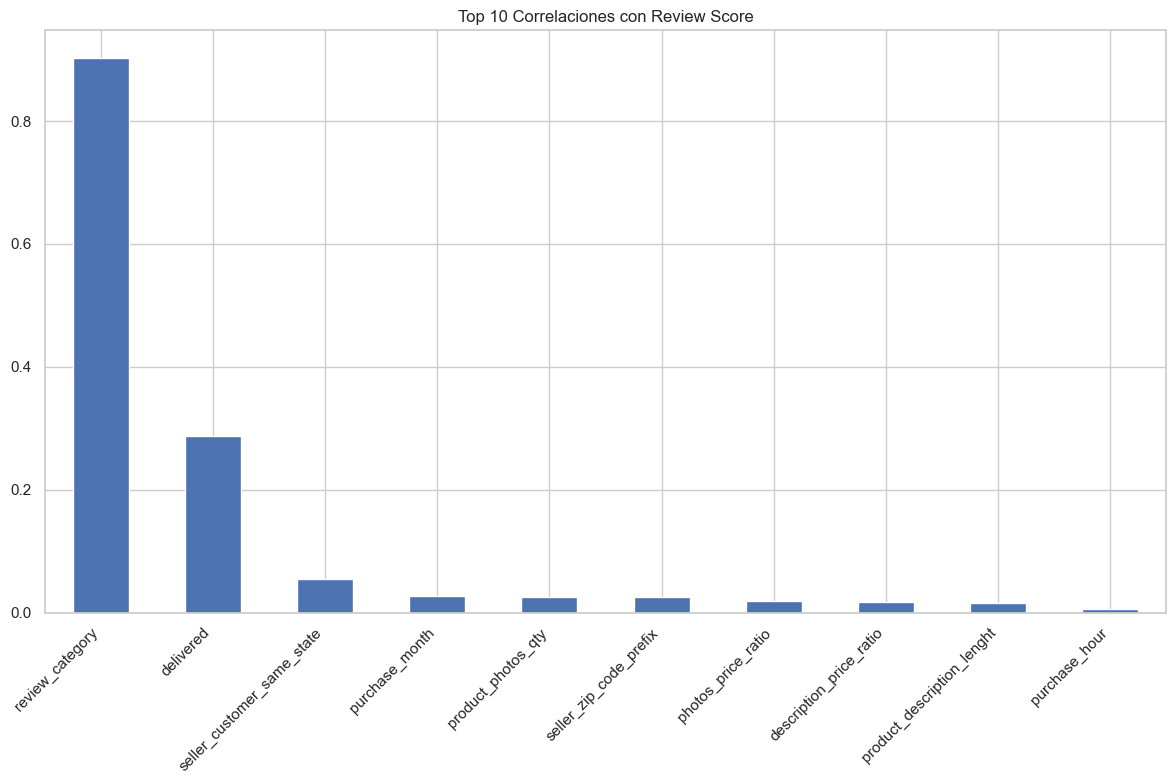

In [8]:
# Seleccionar columnas numéricas para análisis de correlación
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns
corr_matrix = merged_df[numeric_cols].corr()

# Correlaciones con review_score
corr_with_review = corr_matrix['review_score'].sort_values(ascending=False)
print("\nCorrelaciones con review_score (top 10):")
print(corr_with_review.head(11))  # +1 porque incluye la correlación consigo mismo

# Gráfico de correlaciones principales
plt.figure(figsize=(12, 8))
top_corrs = corr_with_review.iloc[1:11]  # Excluir la autocorrelación
top_corrs.plot(kind='bar')
plt.title('Top 10 Correlaciones con Review Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

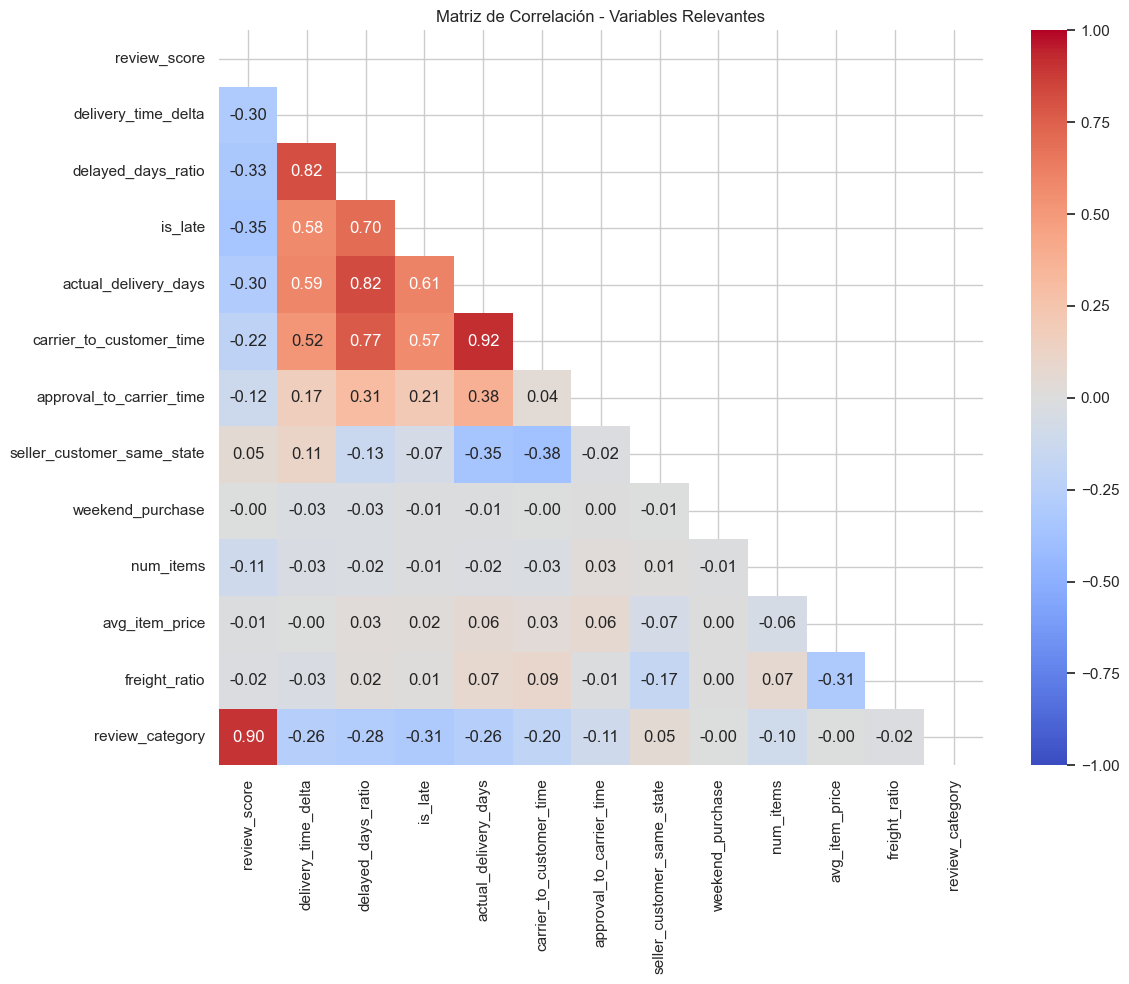

In [9]:
# Matriz de correlación de las variables más importantes
relevant_cols = [
    'review_score', 'delivery_time_delta', 'delayed_days_ratio', 'is_late',
    'actual_delivery_days', 'carrier_to_customer_time', 'approval_to_carrier_time',
    'seller_customer_same_state', 'weekend_purchase', 'num_items',
    'avg_item_price', 'freight_ratio', 'review_category'
]

corr_matrix_relevant = merged_df[relevant_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_relevant, dtype=bool))
sns.heatmap(
    corr_matrix_relevant, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    center=0, 
    fmt='.2f',
    mask=mask
)
plt.title('Matriz de Correlación - Variables Relevantes')
plt.tight_layout()

In [10]:
key_features = [
    # Variables objetivo
    'review_score', 'review_category',
    
    # Variables temporales más importantes
    'delivery_time_delta', 'delayed_days_ratio', 'is_late', 
    'actual_delivery_days', 'carrier_to_customer_time',
    
    # Variables de orden
    'num_items', 'avg_item_price', 'freight_ratio', 'total_order_value',
    
    # Variables de producto
    'product_category_name_english', 'product_volume', 'product_density',
    'product_photos_qty', 'price_per_weight',
    
    # Variables de interacción vendedor-cliente
    'seller_customer_same_state', 'purchase_day_of_week', 'weekend_purchase',
    'purchase_hour', 'purchase_month',
    
    # Variables categóricas importantes
    'customer_state', 'seller_state', 'main_payment_type'
]

# Dataset final
final_df = merged_df[key_features].copy()

output_path = 'merged_dataset_v2.csv'
final_df.to_csv(output_path, index=False)

# Información del dataset final
print(f"\nDataset guardado en: {output_path}")
print(f"Dimensiones del dataset final: {final_df.shape}")
print(f"Columnas incluidas: {final_df.columns.tolist()}")


Dataset guardado en: merged_dataset_v2.csv
Dimensiones del dataset final: (99441, 24)
Columnas incluidas: ['review_score', 'review_category', 'delivery_time_delta', 'delayed_days_ratio', 'is_late', 'actual_delivery_days', 'carrier_to_customer_time', 'num_items', 'avg_item_price', 'freight_ratio', 'total_order_value', 'product_category_name_english', 'product_volume', 'product_density', 'product_photos_qty', 'price_per_weight', 'seller_customer_same_state', 'purchase_day_of_week', 'weekend_purchase', 'purchase_hour', 'purchase_month', 'customer_state', 'seller_state', 'main_payment_type']
